# Final Project Step 2

Sofia Charlot and Tiyamika Williams

# Objective 1 - Set Up Environment & Load Data

In [98]:
import pandas as pd
import numpy as np
import geopandas as gpd

%matplotlib inline

import os
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [99]:
os.getcwd()

'/Users/sofia/Documents/GitHub/BIOS-584'

In [100]:
#Upload, trim dataset, and rename variables. 
places_df = pd.read_excel("data/cdc_places.xlsx")

places_df = places_df[["StateDesc", "CountyName", "TractFIPS", "TotalPopulation", "TotalPop18plus", "FOODSTAMP_CrudePrev", "FOODINSECU_CrudePrev", "HOUSINSECU_CrudePrev", "LACKTRPT_CrudePrev", "Geolocation"]]

places_df = places_df.rename(columns={
    "StateDesc": "state",
    "CountyName": "county",
    "TractFIPS": "tract",
    "TotalPopulation": "total_pop",
    "TotalPop18plus": "adult_pop",
    "FOODSTAMP_CrudePrev": "SNAP_usage",
    "FOODINSECU_CrudePrev": "food_insecure",
    "HOUSINSECU_CrudePrev": "housing_insecure",
    "LACKTRPT_CrudePrev": "trans_barrier",
    "Geolocation": "geolocation",
})



# Objective 2 - Determine Summary Statistics

In [101]:
pd.set_option("display.float_format", "{:.2f}".format)


=== SNAP_usage ===


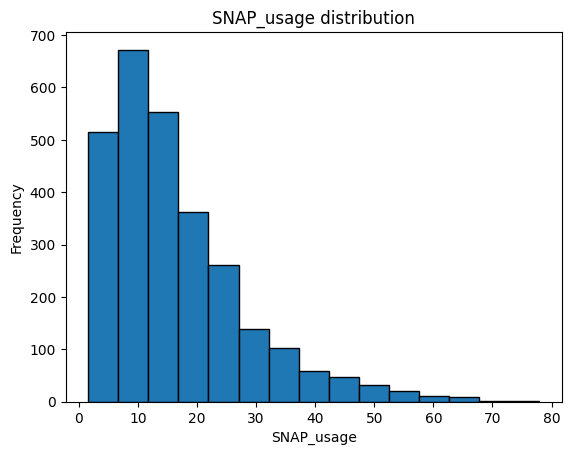


=== food_insecure ===


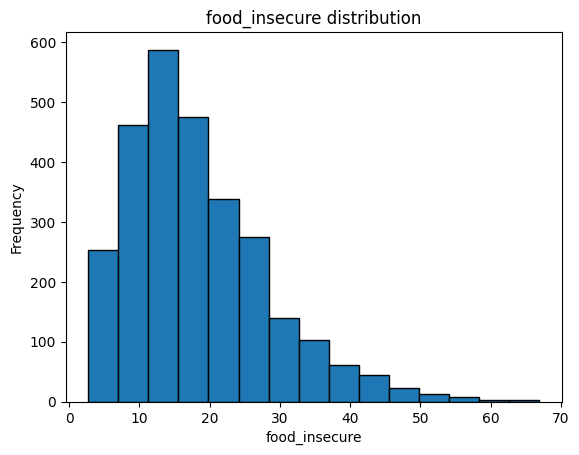


=== housing_insecure ===


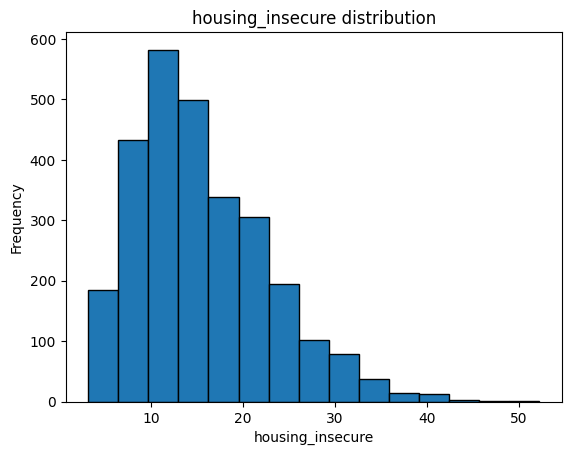


=== trans_barrier ===


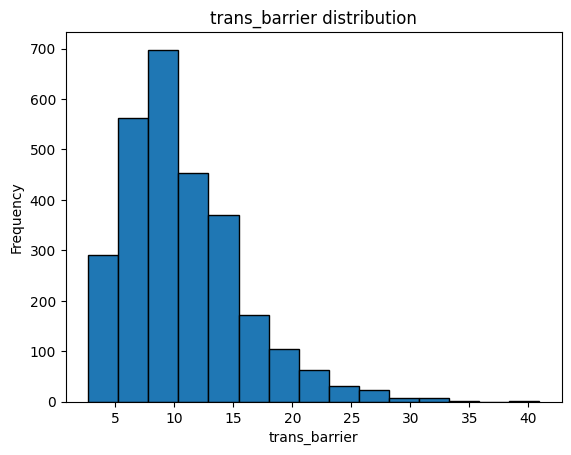

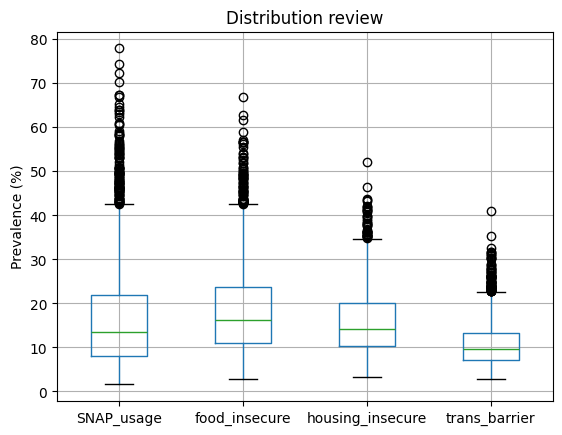

In [102]:
#Check distribution for each variable

#Histogram
analysis_vars = ["SNAP_usage", "food_insecure", "housing_insecure", "trans_barrier"]

for var in analysis_vars:
    print(f"\n=== {var} ===")

    places_df[var].plot(kind='hist', bins=15, edgecolor='black', title=f'{var} distribution')
    plt.xlabel(var)
    plt.show()

#Boxplot
plt.figure()
places_df[analysis_vars].boxplot()
plt.title("Distribution review")
plt.ylabel("Prevalence (%)")
plt.show()

In [103]:
#Produce summary statistics + median + IQR 
summary_stats = places_df[analysis_vars].describe()

summary_stats.loc["missing"] = places_df[analysis_vars].isna().sum()

print(summary_stats)

nonnormal_summary = pd.DataFrame({
    "median": places_df[analysis_vars].median(),
    "Q1": places_df[analysis_vars].quantile(0.25),
    "Q3": places_df[analysis_vars].quantile(0.75),
})

nonnormal_summary["IQR"] = nonnormal_summary["Q3"] - nonnormal_summary["Q1"]

print(nonnormal_summary)

         SNAP_usage  food_insecure  housing_insecure  trans_barrier
count       2784.00        2784.00           2784.00        2784.00
mean          16.46          18.30             15.60          10.69
std           11.63           9.93              7.23           4.99
min            1.60           2.70              3.20           2.70
25%            8.10          11.10             10.30           7.10
50%           13.40          16.30             14.20           9.70
75%           21.90          23.70             20.10          13.30
max           77.90          66.90             52.20          40.90
missing        0.00           0.00              0.00           0.00
                  median    Q1    Q3   IQR
SNAP_usage         13.40  8.10 21.90 13.80
food_insecure      16.30 11.10 23.70 12.60
housing_insecure   14.20 10.30 20.10  9.80
trans_barrier       9.70  7.10 13.30  6.20


Because we are evaluating prevalence data, which is bounded and tends to be skewed, we are reporting both the mean and standard defiation as well as the median and IQR. We are also interested in the minimum and maximums for each variable which might indicate outliers. 

## Summary of Descriptive Statistics

In [104]:
desc_vars = ["food_insecure", "SNAP_usage", "housing_insecure", "trans_barrier", "total_pop", "adult_pop"]

desc_df = places_df[desc_vars].dropna(how="all")

desc = desc_df.describe().T

desc = desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

desc = desc.rename(columns={
    "count": "N",
    "mean": "Mean",
    "std": "SD",
    "min": "Min",
    "25%": "25th percentile",
    "50%": "Median",
    "75%": "75th percentile",
    "max": "Max"
})

summary_table = (
   desc
   .round(2)
   .style.set_caption("Table 1. Summary of Prevalance & Population Measures Across Census Tracts")
   .format({
        "N": "{:.0f}",
        "Mean": "{:.2f}",
        "SD": "{:.2f}",
        "Min": "{:.2f}",
        "25th percentile": "{:.2f}",
        "Median": "{:.2f}",
        "75th percentile": "{:.2f}",
        "Max": "{:.2f}",
    })
)

summary_table

,N,Mean,SD,Min,25th percentile,Median,75th percentile,Max
food_insecure,2784,18.30,9.93,2.70,11.10,16.30,23.70,66.90
SNAP_usage,2784,16.46,11.63,1.60,8.10,13.40,21.90,77.90
housing_insecure,2784,15.60,7.23,3.20,10.30,14.20,20.10,52.20
trans_barrier,2784,10.69,4.99,2.70,7.10,9.70,13.30,40.90
total_pop,2784,3847.67,1469.07,191.00,2767.25,3718.50,4764.50,12356.00
adult_pop,2784,2952.68,1093.79,178.00,2155.75,2865.00,3653.25,8557.00


The descriptive statistics show clear variability in food insecurity and related structural determinants across Metro Atlanta census tracts. Food insecurity ranges from as low as 2.7% to nearly 67%, with a median of 16.3%, demonstrating substantial geographic inequity. SNAP usage, housing insecurity, and transportation barriers display similar spread, indicating uneven distribution of economic hardship across the region. These bounded prevalence variables are right-skewed, which justifies presenting both mean/SD and median/IQR. Together, these results illustrate that communities experience material hardship at very different levels, underscoring the importance of examining the structural drivers behind these disparities.

# Objective 3 - Statistical Analysis Plan

For this project, our statistical aim is to understand food insecurity across the Metro Atlanta area and how it relates to the sociodemographic factors included in the CDC PLACES dataset. We want to know what food insecurity levels look like across the region, which sociodemographic factors show meaningful associations with food insecurity, and how strongly those factors help us describe or predict food insecurity at the census-tract level. The sociodemographic factors of interest are housing insecurity, transportation barriers, and SNAP usage. This analysis guides how we think about the structural determinants that shape food access in local communities.

To begin the analysis, we will explore the dataset to understand the distribution of each variable. This includes reviewing histograms and boxplots and calculating summary statistics such as the mean, median, standard deviation, interquartile range, minimum, and maximum values. Because we are evaluating prevalence data at the census-tract level, we will not access normality using statistical tests. Instead, we will assess distributions using histograms and boxplots, as well as descriptive summary statistics. These steps help us determine which descriptive measures are most appropriate for reporting and prepare us for the analysis that follows.
 
To examine whether food insecurity differs across levels of sociodemographic characteristics, we will conduct a series of bivariate analyses. Because all predictors are continuous prevalence measures, we will calculate Pearson correlation coefficients to measure the strength and direction of the association between food insecurity and sociodemographic factors. To further investigate how sociodemographic factors predict food insecurity, we will run simple linear regression models. Each model will include food insecurity as the outcome variable and one sociodemographic predictor at a time. Predictors include housing insecurity prevalence, transportation barriers prevalence, and SNAP usage prevalence. For each model, we will report the regression coefficients and their confidence intervals to describe how food insecurity changes as the predictor increases. We will also review residual diagnostic plots to assess model fit and confirm if linear regression assumptions are met.

We will include several tables and figures to support our analysis. Table 1 will summarize descriptive statistics for all variables. Table 2 will present the correlation coefficients from our bivariate analyses. Table 3 will present the regression results for each predictor. Figure 1 will be a choropleth map showing food insecurity prevalence across the Metro Atlanta area to address the question, “How does food insecurity vary across the Metro Atlanta area?” Figure 2 will include scatterplots with fitted linear regression lines that visualize the association between food insecurity and each potential predictor. These visuals will help address the question, “What health-related sociodemographic characteristics are associated with food insecurity in the Metro Atlanta area?”

All analyses will be conducted using Python. We will use pandas and numpy for data cleaning and management, scipy.stats for Pearson correlations, and statsmodels for all regression models. Figures will be produced using matplotlib.

# Data Analysis

## Pearson Correlation Matrix across Food Insecurity and all Predictors

In [105]:
# Create a correlation matrix for the predictor variables
predictors = [
    "SNAP_usage",
    "food_insecure",
    "housing_insecure",
    "trans_barrier"
]

analysis_df = places_df[predictors].copy()

for col in predictors:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

analysis_df = analysis_df.dropna(subset=predictors)

corr_matrix = analysis_df.corr(method="pearson")

corr_matrix = (
    corr_matrix
    .style
    .set_caption("Table 2a: Pearson Correlation Matrix for Food Insecurity and Predictors")
    .format("{:.2f}")
                )
corr_matrix

,SNAP_usage,food_insecure,housing_insecure,trans_barrier
SNAP_usage,1.00,0.99,0.96,0.98
food_insecure,0.99,1.00,0.98,0.99
housing_insecure,0.96,0.98,1.00,0.98
trans_barrier,0.98,0.99,0.98,1.00


In [106]:
#Calculate correlations with p-values
def p_corr_with_p(analysis_df, outcome, predictors):

    results = []

    for pred in predictors:
        r, p = stats.pearsonr(analysis_df[outcome], analysis_df[pred])
        results.append({
            "predictor": pred,
            "pearson_r": r,
            "p_value": p
        })

    return pd.DataFrame(results)

outcome_var = "food_insecure"
predictors = ["SNAP_usage", "housing_insecure", "trans_barrier"]

corr_results = p_corr_with_p(analysis_df, outcome_var, predictors)

In [107]:
corr_results_table = (
    corr_results
    .style
    .set_caption("Table 2b: r and p-values for Food Insecurity and Predictors Correlation")
    .format({
        "pearson_r": "{:.2f}",
        "p_value": "{:.4f}",
    })
)
corr_results_table

,predictor,pearson_r,p_value
0,SNAP_usage,0.99,0.0000
1,housing_insecure,0.98,0.0000
2,trans_barrier,0.99,0.0000


The correlation analysis highlights strong and consistent relationships between food insecurity and all three sociodemographic predictors. Food insecurity is positively correlated with housing insecurity, transportation barriers, and SNAP usage, indicating that communities facing higher structural barriers also experience higher rates of food insecurity.

## Simple Linear Regression

In [108]:
# Create a function to run the simple linear regression models
def simp_lin_reg(analysis_df, outcome, predictor):

    formula = f"{outcome} ~ {predictor}"
    model = smf.ols(formula=formula, data=analysis_df).fit()
    return model

In [109]:
# Fit the model for each predictor
models = {}

for pred in predictors:
    model = simp_lin_reg(analysis_df, outcome_var, pred)
    models[pred] = model
    print(f"\n=== Model: {outcome_var} ~ {pred} ===")
    print(model.summary())


=== Model: food_insecure ~ SNAP_usage ===
                            OLS Regression Results                            
Dep. Variable:          food_insecure   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 1.108e+05
Date:                Fri, 05 Dec 2025   Prob (F-statistic):               0.00
Time:                        11:06:04   Log-Likelihood:                -5177.0
No. Observations:                2784   AIC:                         1.036e+04
Df Residuals:                    2782   BIC:                         1.037e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept

The model examining SNAP usage shows a very strong linear relationship with food insecurity (R² = 0.975). For every 1-percentage-point increase in SNAP usage, food insecurity increases by 0.84 percentage points (β = 0.8428, 95% CI: 0.838 to 0.848). The intercept of 4.42% reflects the expected level of food insecurity in tracts with virtually no SNAP participation. The extremely high t-value (332.8) and a p-value of < 0.001 demonstrate that this association is highly statistically significant. These results indicate that SNAP usage, as a proxy for community-level economic hardship, is strongly aligned with food insecurity across Metro Atlanta.

In [119]:
# Create a table of coefficients and confidence intervals
reg_results = []

for pred, model in models.items():
    params = model.params
    conf = model.conf_int()

    beta = params[pred]
    ci_low = conf.loc[pred, 0]
    ci_high = conf.loc[pred, 1]
    p_value = model.pvalues[pred]
    r_squared = model.rsquared

    reg_results.append({
        "predictor": pred,
        "beta": beta,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_value": p_value,
        "r_squared": r_squared
    })

reg_results_df = pd.DataFrame(reg_results)

In [111]:
reg_results_table = (
    reg_results_df
    .style
    .set_caption("Table 3: Linear Regression Results")
    .format({
        "ci_low": "{:.4f}",
        "ci_high": "{:.4f}",
        "p_value": "{:.4f}",
        "r_squared": "{:.4f}",
        "beta": "{:.4f}",
    })
)
reg_results_table

,predictor,beta,ci_low,ci_high,p_value,r_squared
0,SNAP_usage,0.8428,0.8379,0.8478,0.0000,0.9755
1,housing_insecure,1.3459,1.3360,1.3558,0.0000,0.9622
2,trans_barrier,1.9759,1.9668,1.9850,0.0000,0.9848


## Create a function to access the model

In [112]:
# Model diagnostics function
def plot_diagnostics(model, title_suffix=""):

    fitted = model.fittedvalues
    residuals = model.resid

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    #residuals vs fitted
    axes[0].scatter(fitted, residuals, alpha=0.7)
    axes[0].axhline(0, linestyle="--")
    axes[0].set_xlabel("Fitted values")
    axes[0].set_ylabel("Residuals")
    axes[0].set_title(f"Residuals vs Fitted {title_suffix}")

    #histogram of residuals 
    axes[1].hist(residuals, bins=20, edgecolor="black")
    axes[1].set_xlabel("Residual")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title(f"Residual Histogram {title_suffix}")

    #Q-Q plot
    sm.qqplot(residuals, line="45", ax=axes[2])
    axes[2].set_title(f"Normal Q-Q Plot {title_suffix}")

    plt.tight_layout()
    plt.show()


=== Diagnostic Plots for model: food_insecure ~ SNAP_usage ===


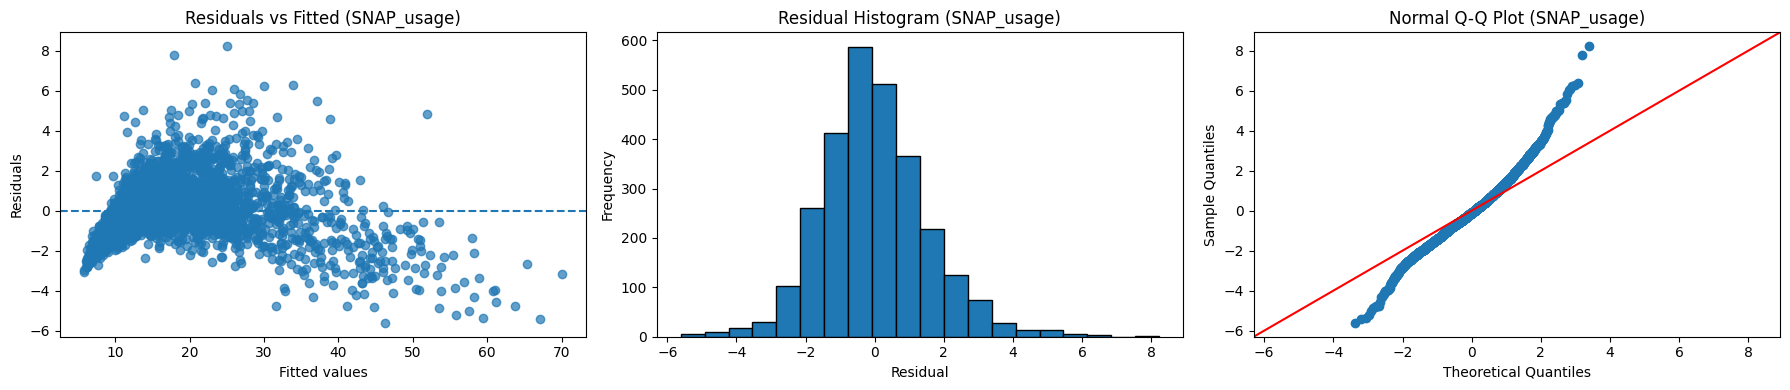


=== Diagnostic Plots for model: food_insecure ~ housing_insecure ===


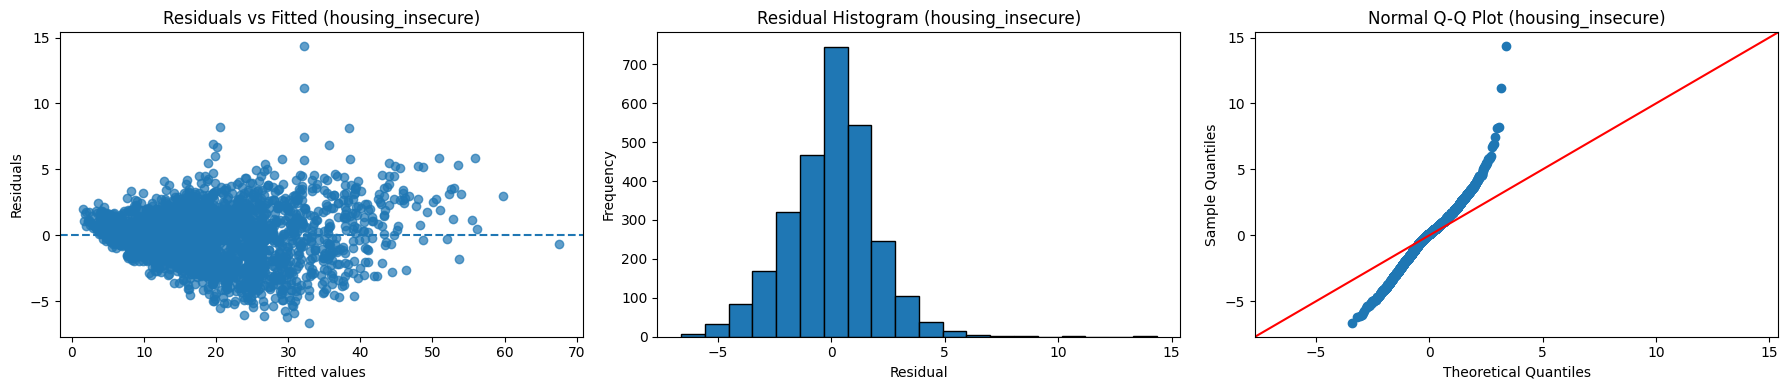


=== Diagnostic Plots for model: food_insecure ~ trans_barrier ===


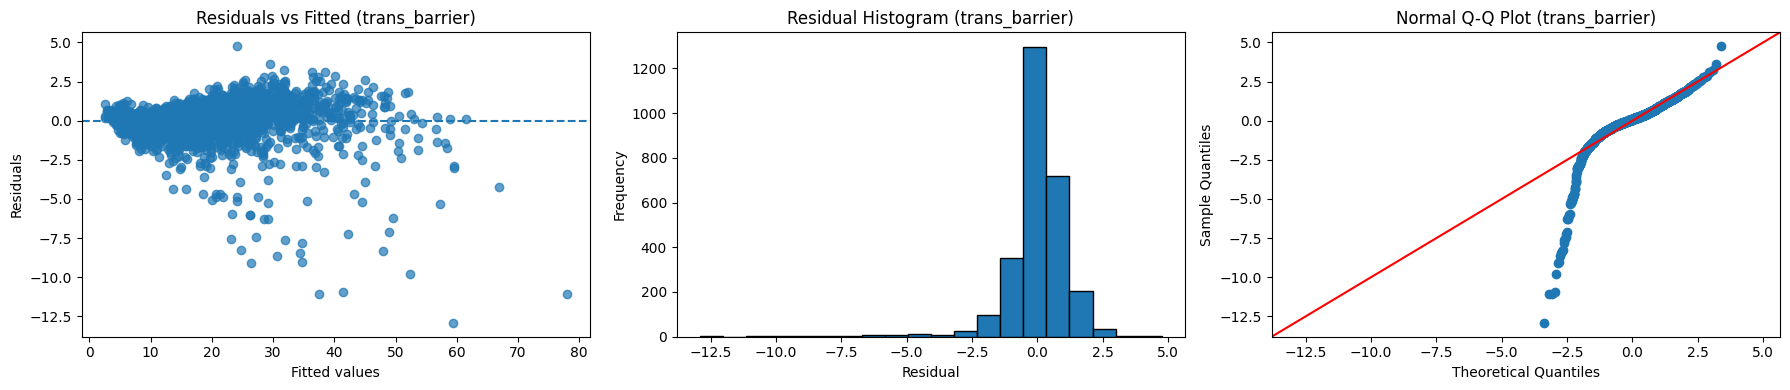

In [113]:
#Run diagnostics for each model
for pred, model in models.items():
    print(f"\n=== Diagnostic Plots for model: {outcome_var} ~ {pred} ===")
    plot_diagnostics(model, title_suffix=f"({pred})")

# Objective 4 - Figure Descriptions

Figure 1: Our dataset reports food insecurity at the census-tract level and includes point data for US census tracts. Figure 1 will be a choropleth map of food insecurity prevalence across the Metro Atlanta area. It will be titled, "Food Insecurity across Metro Atlanta area Census Tracts." Census tract boundaries will be clearly outlined. The map will use longitude for the x-axis and latitude for the y-axis, but those labels and the numeric values won't be displayed since the focus is on mapping spatial patterns. Each census tract will be shaded according to the corresponding food insecurity prevalence. A legend, titled "Food Insecurity Prevalence (%)", will include a color scale where a darker shade means a higher prevalence of food insecurity and a lighter shade means a lower prevalence of food insecurity. This figure will answer the research question, “How does food insecurity vary across the Metro Atlanta area?”

Figure 2: Figure 2 will include a series of scatterplots visualizing the association between food insecurity and each potential predictor (housing insecurity, transportation barriers, and SNAP usage). Each scatterplot will have "Food Insecurity Prevalence (%)" on the x-axis and a single predictor on the y-axis. The points on the scatterplot will represent each census tract's food insecurity prevalence. Each plot will have a linear regression line to visualize the direction and strength of the relationship between food insecurity prevalence and each predictor. This figure will inform the following research question, "What health-related sociodemographic characteristics are associated with Food insecurity in the Metro Atlanta area?"

# Findings Graphics

## Figure 1

In [114]:
#Add GEOID column 
fi_list = [
    "tract",
    "food_insecure",
    "geolocation"
]

fi_df = places_df[fi_list].copy()

geoid_df = pd.read_excel("data/tract_data.xlsx")

fi_df["TRACT_KEY"] = fi_df["tract"].astype(str).str.zfill(11)
geoid_df["TRACT_KEY"] = geoid_df["GEOID"].astype(str).str.zfill(11)

geoid_small = geoid_df[["TRACT_KEY", "GEOID"]].drop_duplicates()

fi_w_geoid = fi_df.merge(
    geoid_small,
    on="TRACT_KEY",
    how="left"
)  

In [115]:
#Load tract polygons
tract_gdf = gpd.read_file("data/tract_shp/tl_2022_13_tract.shp")
tract_gdf["GEOID"] = tract_gdf["GEOID"].astype(str).str.zfill(11)
fi_w_geoid["GEOID"] = fi_w_geoid["GEOID"].astype(str).str.zfill(11)

tract_gdf[["GEOID", "geometry"]].head()

#Merge with food insecurity data
merged_gdf = tract_gdf.merge(
    fi_w_geoid[["GEOID", "food_insecure"]],
    on="GEOID",
    how="left"
)

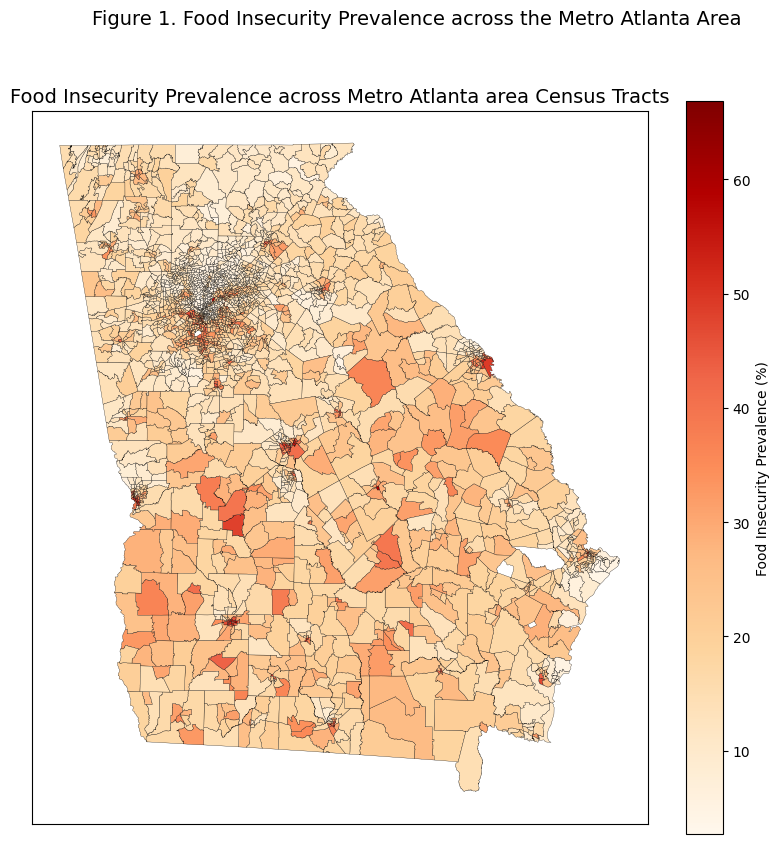

In [116]:
# Plot figure 1
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

merged_gdf.plot(
    column="food_insecure",
    ax=ax,
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True
)

# The colorbar is usually the second axes in the figure
cbar_ax = fig.axes[1]
cbar_ax.set_ylabel("Food Insecurity Prevalence (%)")

ax.set_title("Food Insecurity Prevalence across Metro Atlanta area Census Tracts", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])

fig.suptitle(
    "Figure 1. Food Insecurity Prevalence across the Metro Atlanta Area",
    fontsize=14,
    y=1.05
)

plt.tight_layout()
plt.show()

## Figure 2

In [117]:
scatter_list = [
    "food_insecure",
    "SNAP_usage",
    "housing_insecure",
    "trans_barrier"
]

scatter_df = places_df[scatter_list].copy()

predictors = [
    ("SNAP_usage", "SNAP Usage Prevalence (%)"),
    ("housing_insecure", "Housing Insecurity Prevalence (%)"),
    ("trans_barrier", "Transportation Barriers Prevalence (%)"),
]

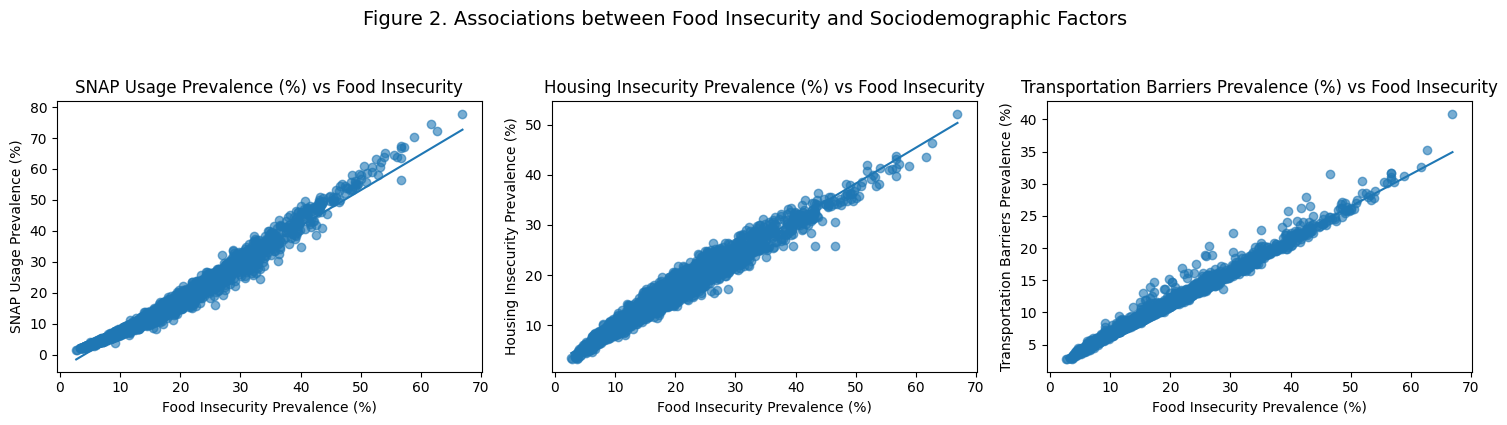

In [118]:
n_preds = len(predictors)

fig, axes = plt.subplots(
    1, n_preds,
    figsize=(5 * n_preds, 4),
    sharex=True
)

if n_preds == 1:
    axes = [axes]


x = scatter_df["food_insecure"]
x_min, x_max = x.min(), x.max()
x_range = np.linspace(x_min, x_max, 100)

for ax, (pred_col, y_label) in zip(axes, predictors):
    y = scatter_df[pred_col]
    
    # Drop any rows with missing values for this pair
    mask = ~(x.isna() | y.isna())
    x_clean = x[mask]
    y_clean = y[mask]
    
    # Scatter points (each point = census tract)
    ax.scatter(x_clean, y_clean, alpha=0.6)
    
    # Fit and plot a simple linear regression line: y = slope * x + intercept
    if len(x_clean) > 1:
        slope, intercept = np.polyfit(x_clean, y_clean, 1)
        y_line = slope * x_range + intercept
        ax.plot(x_range, y_line)
    
    # Axis labels
    ax.set_xlabel("Food Insecurity Prevalence (%)")
    ax.set_ylabel(y_label)
    
    # Title for each panel
    ax.set_title(f"{y_label} vs Food Insecurity")

# Overall figure title
fig.suptitle(
    "Figure 2. Associations between Food Insecurity and Sociodemographic Factors",
    fontsize=14,
    y=1.05
)

plt.tight_layout()
plt.show()